# Bidirectional Hex-Star: Forward vs Reverse Velocity Example
This notebook demonstrates a concrete multi-turn path and evaluates:
- Forward velocity propagation
- Reverse (inverse) propagation
- Join-node compatibility


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, get_neighbors_at_radius, VelocityState, image_to_hex_obstacles, hexes_in_between_solid
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, HStarProblem, BidHStarSearch
from hexplot import plot_hex_grid_2, plot_velocity_profile

import matplotlib.pyplot as plt
import itertools

In [19]:
RADIUS = 50
a_max = 3
a_min = 2
ay_window_ms = 6

collision_radius = 0

jps_horizon = None
n_step = 5

In [20]:
obs_density = 0.15
hex_size = 1
n_obs = int(obs_density * 3 * RADIUS * (RADIUS + 1))
start = HexCoord(q=-RADIUS + 4, r=RADIUS - 4)
goal = HexCoord(q=RADIUS - 4, r=-RADIUS + 4)

obs = build_obstacle_map(
    center = HexCoord(0,0),
    radius = RADIUS,
    types = [("random_n", {"n": n_obs})],
    exclude=[start, goal],
    seed=42
)

obs = set(obs.keys())
from hexgrid import hexes_in_between_solid

from_hex = HexCoord(q = -RADIUS//2, r = -RADIUS // 2)
to_hex = HexCoord(q = RADIUS // 2 - 5, r = RADIUS // 2 - 5)
line = hexes_in_between_solid(from_hex, to_hex) 
obs = obs.union(line)

from_hex = HexCoord(q = RADIUS, r = -RADIUS//2)
to_hex = HexCoord(q =  5, r =  -5)
line = hexes_in_between_solid(from_hex, to_hex) 
obs = obs.union(line)

for i in range(5):
    obs = obs - get_neighbors_at_radius(start, i)
    obs = obs - get_neighbors_at_radius(goal, i)


obs = obs.union(get_neighbors_at_radius(HexCoord(0,0), RADIUS))

<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Jump Points Reverse'}, xlabel='x', ylabel='y'>

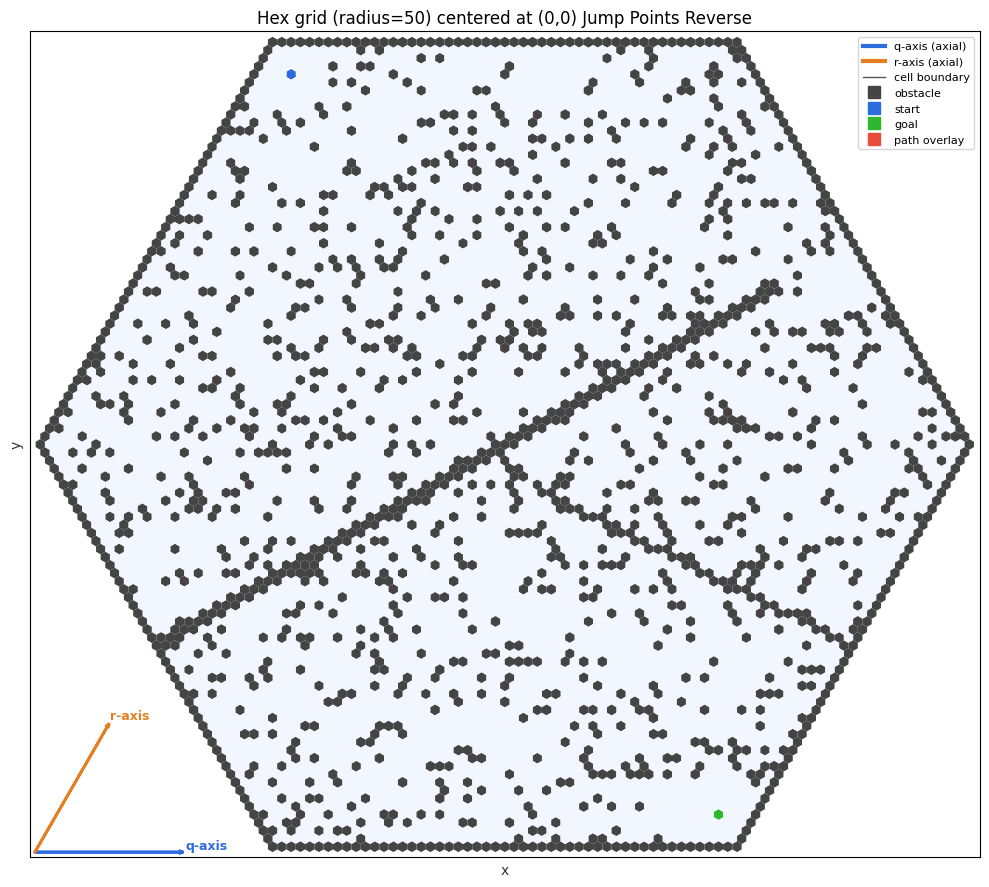

In [21]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    #path = set([n.location for n in bi_solution]),
    linewidth=0,
    plt_title = f"Jump Points Reverse",
    save_path=f"jump-points-reverse",
)

In [26]:
hg = HexGrid(hex_size, obs)

problem = HStarProblem(
    hg, # hex grid
    start,
    goal,
    a_max,  # maximum acceleration (for acceleration phase)
    a_min,  # maximum deceleration (positive value; used with sign as needed)
    collision_radius = collision_radius,
    jps_horizon =  jps_horizon,
    ay_window_ms = ay_window_ms,
    n_step = n_step,   
    start_v = VelocityState(25, None),
    goal_v = VelocityState(10, None)
)


In [27]:
hs = HStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time
)

fsolution = hs.search()
fsolution_path = construct_full_solution(fsolution)
benchmarks = hs.get_benchmarks()
print(f'Search time: {benchmarks["search_time"]}s')
print(f'Solution cost: {benchmarks["solution_cost"]}')

Search time: 42.91742420196533s
Solution cost: 14.197784806203902


<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Full Path'}, xlabel='x', ylabel='y'>

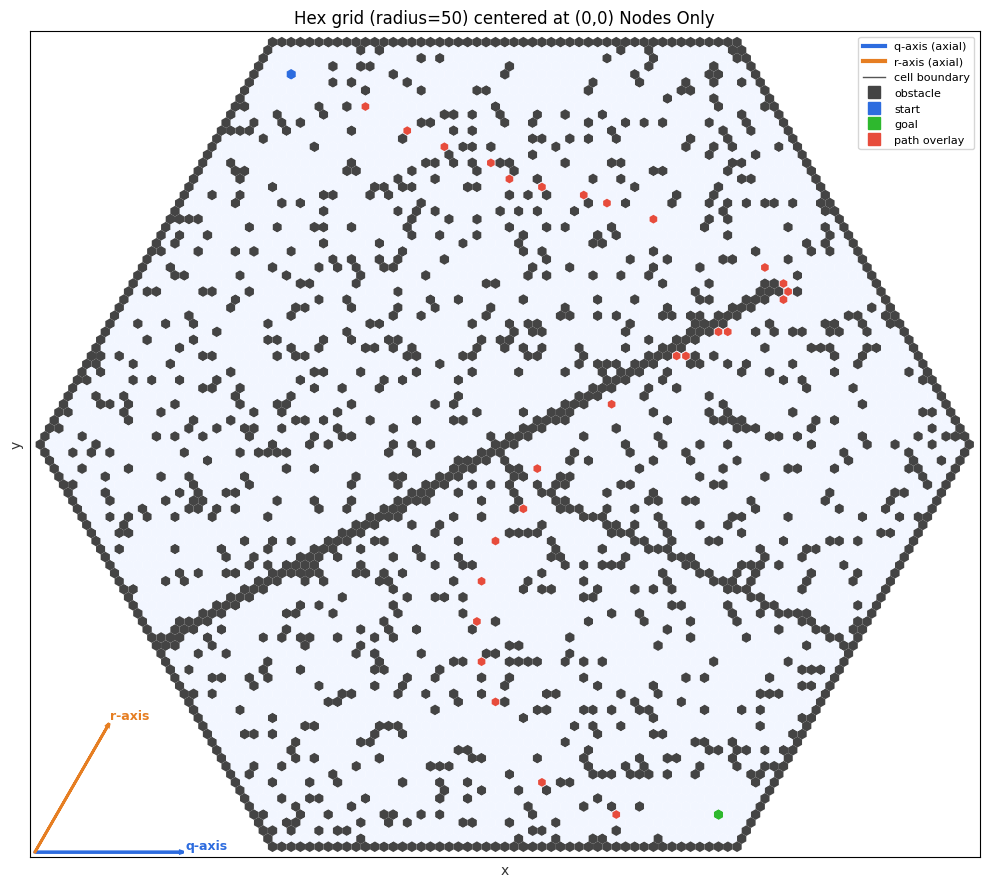

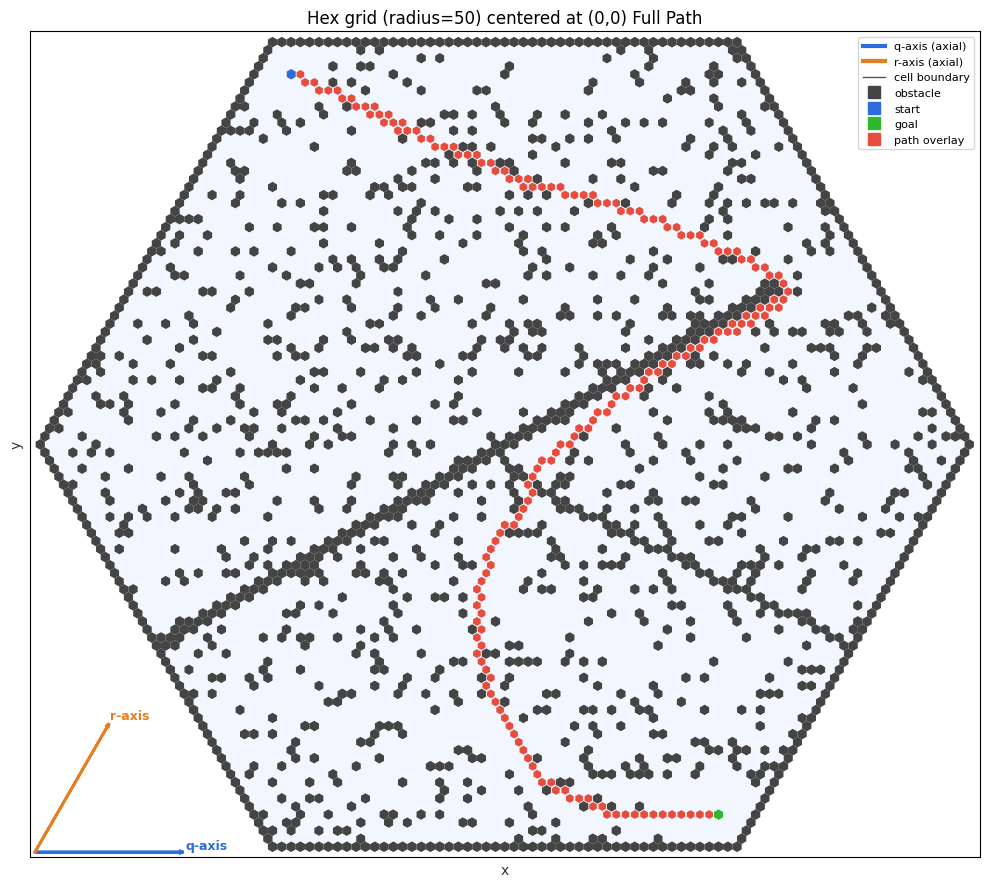

In [28]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in fsolution]),
    linewidth=0,
    plt_title = f"Nodes Only",
    save_path=f"nodes",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = fsolution_path,
    linewidth=0,
    plt_title = f"Full Path",
    save_path=f"fullpath",
)

In [29]:
bi_s = BidHStarSearch(
    problem = problem,
    heuristic = h_cost_travel_time,
    join_tolerance =1,
    enable_benchmarking=True,
    state_key_mode="location",
    progress_every=1,
    progress_top_k=3,
)

bi_solution = bi_s.search()
bi_solution_path = construct_full_solution(bi_solution)

benchmarks_bi = bi_s.get_benchmarks()
print(f'Search time: {benchmarks_bi["search_time"]}s')
print(f'Solution cost bd: {benchmarks_bi["solution_cost"]}')
print(f'Solution cost f: {benchmarks["solution_cost"]}')



[JOIN DEBUG]
expanding_forward=False
join_tolerance=1
epsilon=1e-09
----------------------------------------------------------------------------------------------------
child:
  loc=HexCoord(q=8, r=-9)
  vel=(mag=13.210507836653, dir=34 -> HexCoord(q=-5, r=2) | reverse=4 -> HexCoord(q=5, r=-2))
  g_cost=5.08209957648
  h_cost=5.179998465134
  f_cost=10.262098041614
  step_distance=7.549834435270749
  parent_loc=HexCoord(q=13, r=-11)
  parent_vel=(mag=12.013250166428, dir=40 -> HexCoord(q=-1, r=1) | reverse=10 -> HexCoord(q=1, r=-1))
----------------------------------------------------------------------------------------------------
other:
  loc=HexCoord(q=8, r=-9)
  vel=(mag=10.602356529148, dir=12 -> HexCoord(q=3, r=-4) | reverse=42 -> HexCoord(q=-3, r=4))
  g_cost=9.872183014401
  h_cost=3.973784756172
  f_cost=13.845967770574
  step_distance=6.244997998398398
  parent_loc=HexCoord(q=5, r=-5)
  parent_vel=(mag=8.656787855826, dir=22 -> HexCoord(q=-1, r=-3) | reverse=52 -> HexCoord(q

<Axes: title={'center': 'Hex grid (radius=50) centered at (0,0) Full Path'}, xlabel='x', ylabel='y'>

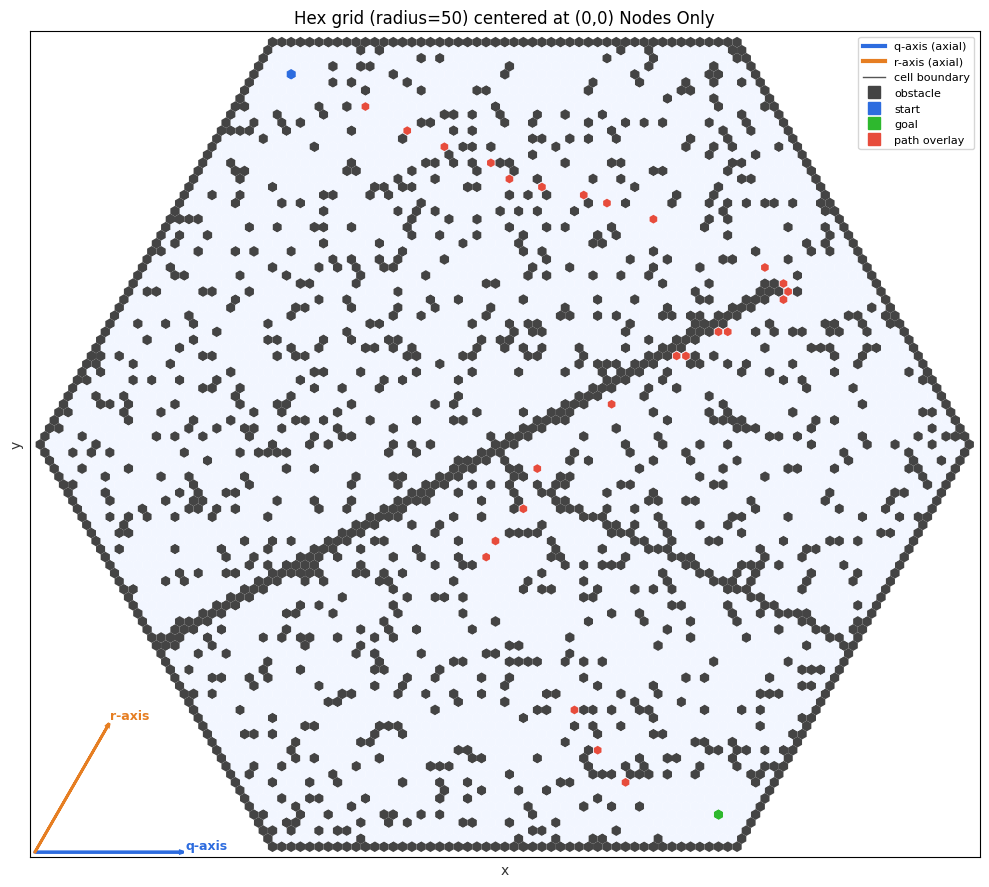

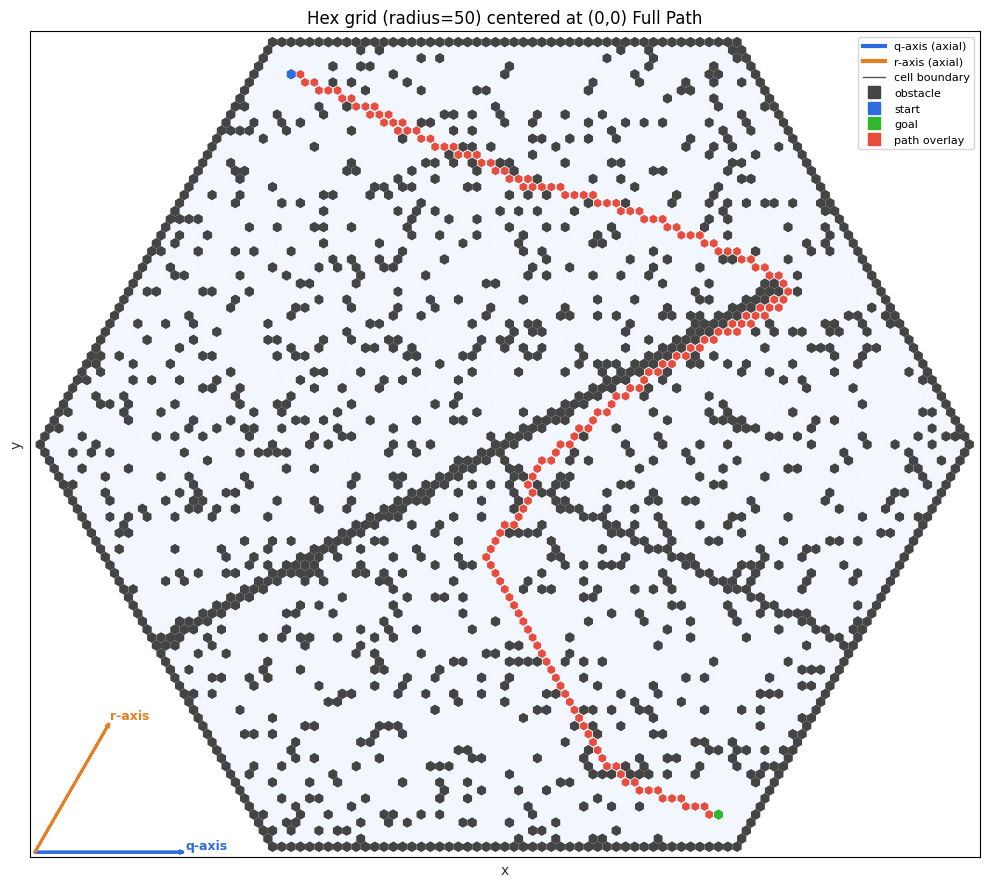

In [30]:
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = set([n.location for n in bi_solution]),
    linewidth=0,
    plt_title = f"Nodes Only",
    save_path=f"nodes",
)
plot_hex_grid_2(
    obs,
    start,
    HexCoord(0,0),
    RADIUS,
    goal = goal,
    figsize=(10,10),
    show_coords = False,
    path = bi_solution_path,
    linewidth=0,
    plt_title = f"Full Path",
    save_path=f"fullpath",
)

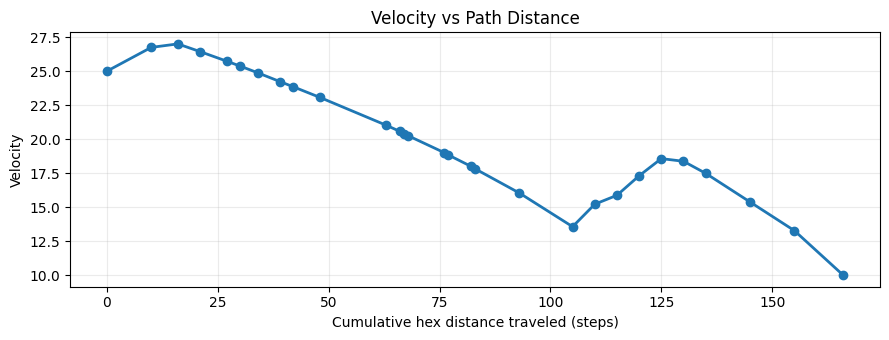

<Axes: title={'center': 'Velocity vs Path Distance'}, xlabel='Cumulative hex distance traveled (steps)', ylabel='Velocity'>

In [31]:
from hexplot import plot_velocity_profile
plot_velocity_profile(fsolution, savepath='vel.png')